# Experiment 0 — pilot run

Goal: **does every method run end-to-end** on every dataset? One fold, no HPO; numbers are indicative. Foundation models are highlighted in red in every chart. Figures → `figures/experiment0/` (wiped on rerun).

In [1]:
import sys
from pathlib import Path
PROJECT_ROOT = Path.cwd().parent if Path.cwd().name == 'notebooks' else Path.cwd()
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

from src.utils.paths import results_root
from src.visualizations.experiment_plots import (
    apply_style, reset_figure_dir, load_summary,
    performance_heatmap, method_ranking_bars, learning_curve, imbalance_curve,
    metric_boxplots, metric_bars, compute_time_bars, compute_time_boxplot,
    rank_heatmap, rank_boxplots, hpo_improvement_bars, runtime_performance_scatter,
    pd_summary_text, lgd_summary_text,
)
apply_style()

RESULTS_ROOT = results_root()          # override here if your copy lives elsewhere
SUMMARY_DIR  = RESULTS_ROOT / 'summaries'
FIGURES_DIR  = reset_figure_dir(PROJECT_ROOT / 'figures' / 'experiment0')
print('results:', RESULTS_ROOT, '| figures:', FIGURES_DIR)

results: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\results | figures: C:\Users\U0152019\PhD Documents\Projects\1. TabPFN\TabPFNCredit\figures\experiment0


In [2]:
df = load_summary(SUMMARY_DIR, experiment='experiment0', task='pd', aggregated=False)
try:
    df_lgd = load_summary(SUMMARY_DIR, experiment='experiment0', task='lgd', aggregated=False)
except FileNotFoundError:
    df_lgd = None
print(f'PD: {df["method"].nunique()} methods x {df["dataset"].nunique()} datasets')

PD: 42 methods x 14 datasets


## Coverage — which methods produced a result on every dataset?

In [3]:
cov = df.groupby('method')['dataset'].nunique().sort_values(); n_ds = df['dataset'].nunique()
print(cov[cov < n_ds].to_string() if (cov < n_ds).any() else 'full coverage on all PD datasets')

full coverage on all PD datasets


## PD — AUC

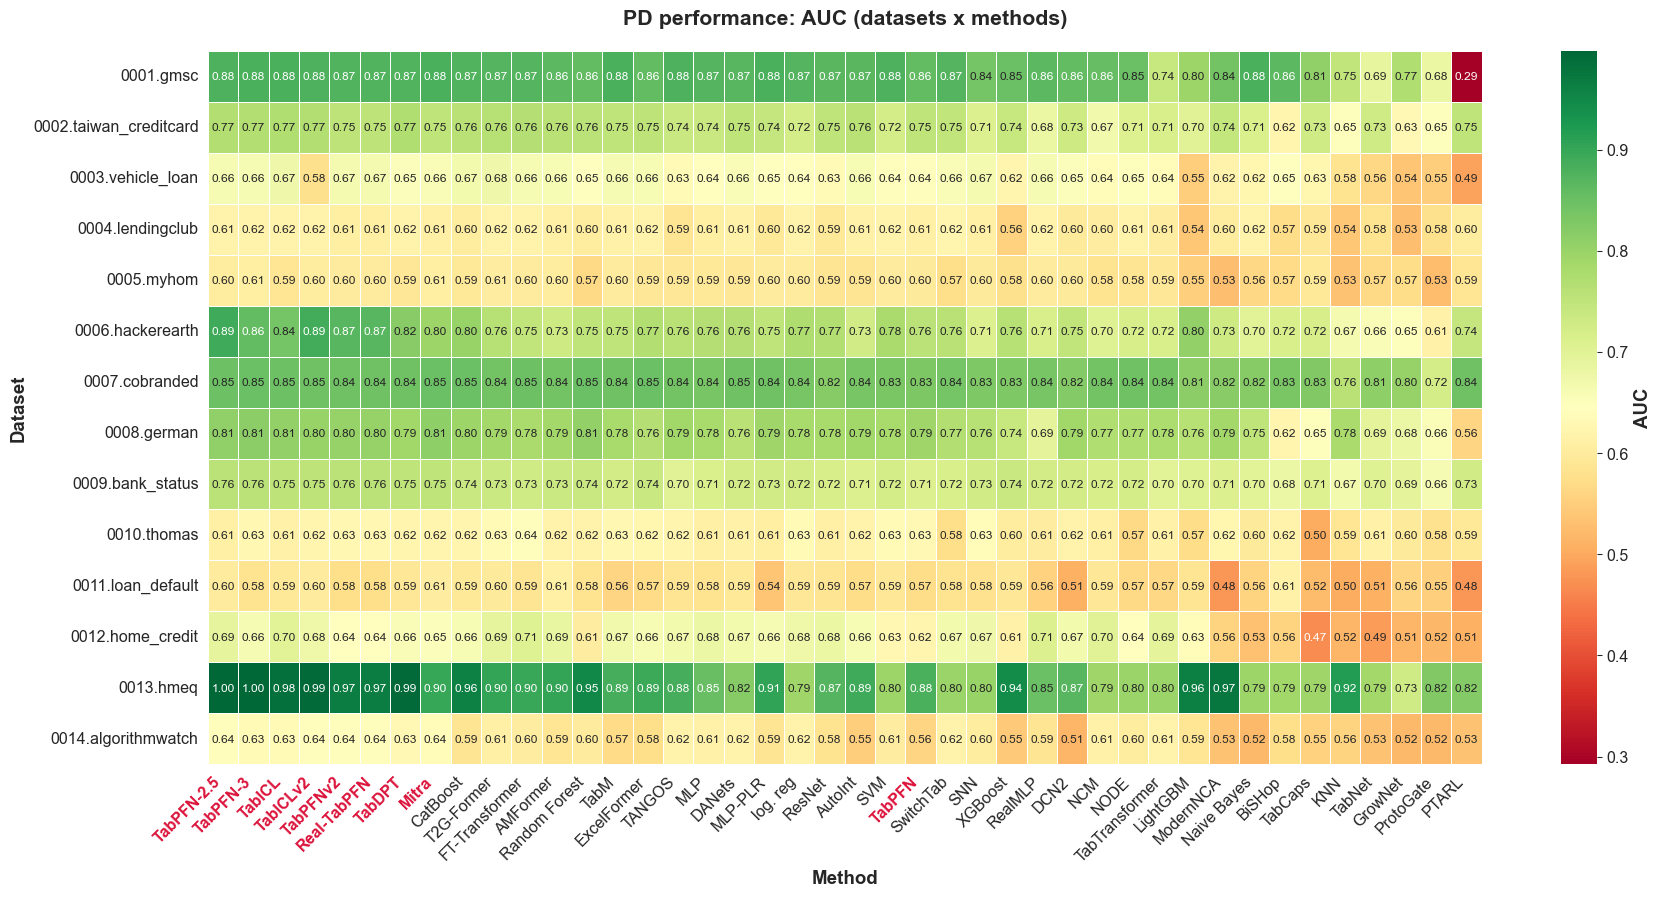

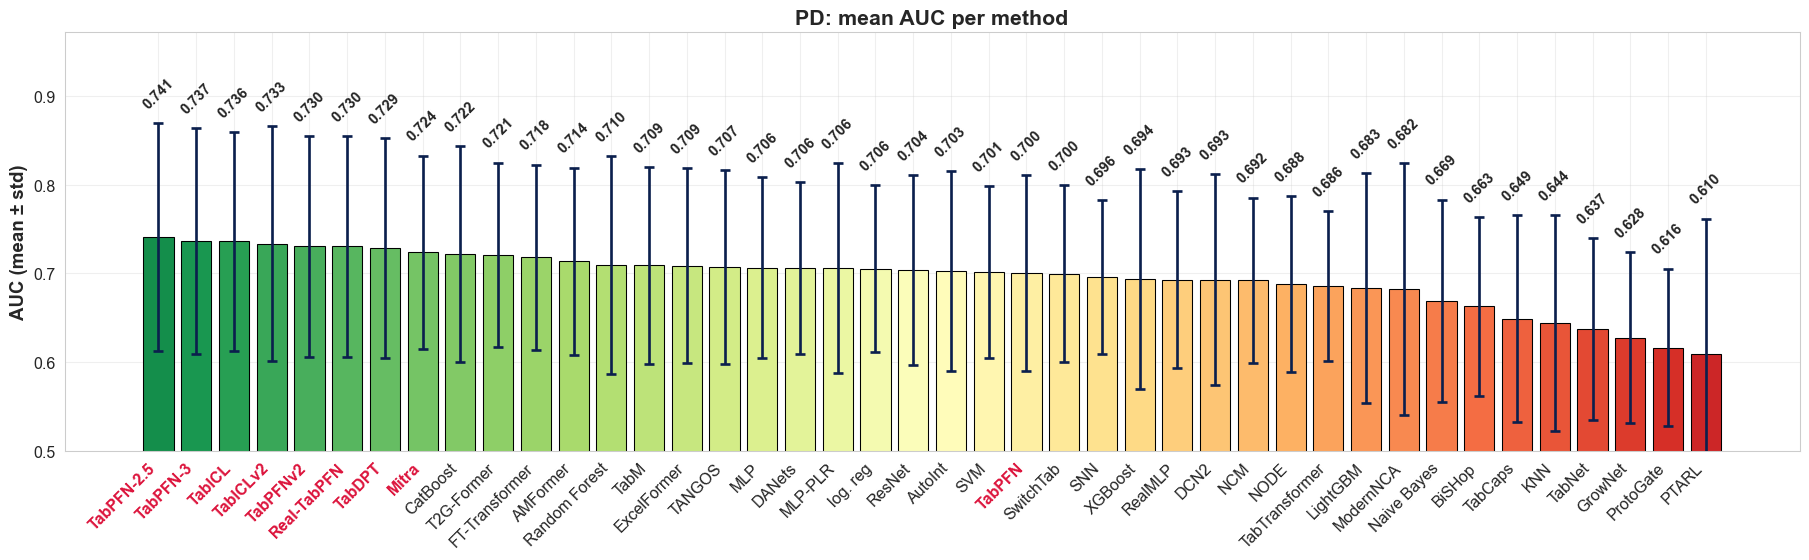

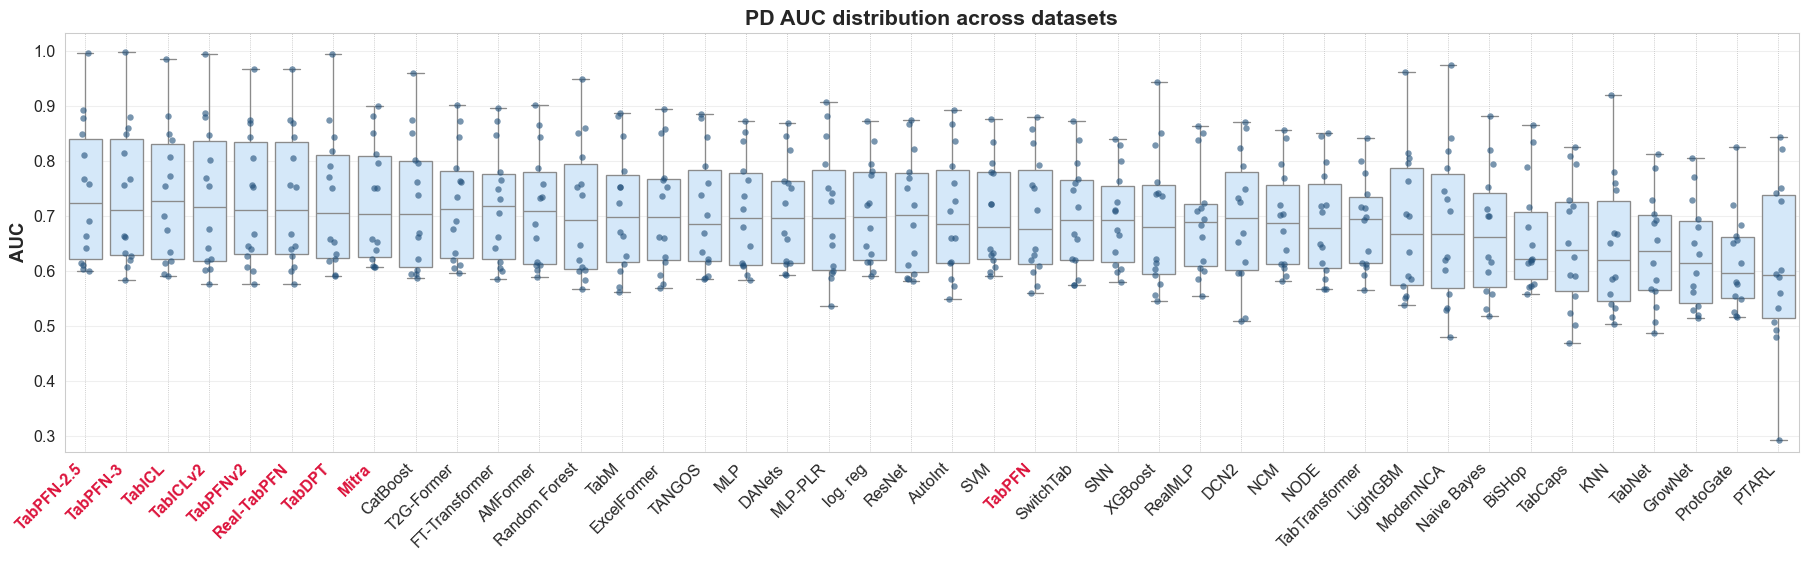

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment0/pd_box_auc.pdf')

In [4]:
performance_heatmap(df, 'AUC', task_name='PD', higher_is_better=True, out_dir=FIGURES_DIR)
metric_bars(df, 'AUC', task_name='PD', higher_is_better=True, out_dir=FIGURES_DIR)
metric_boxplots(df, 'AUC', task_name='PD', higher_is_better=True, out_dir=FIGURES_DIR)

## PD — compute time + cost/quality

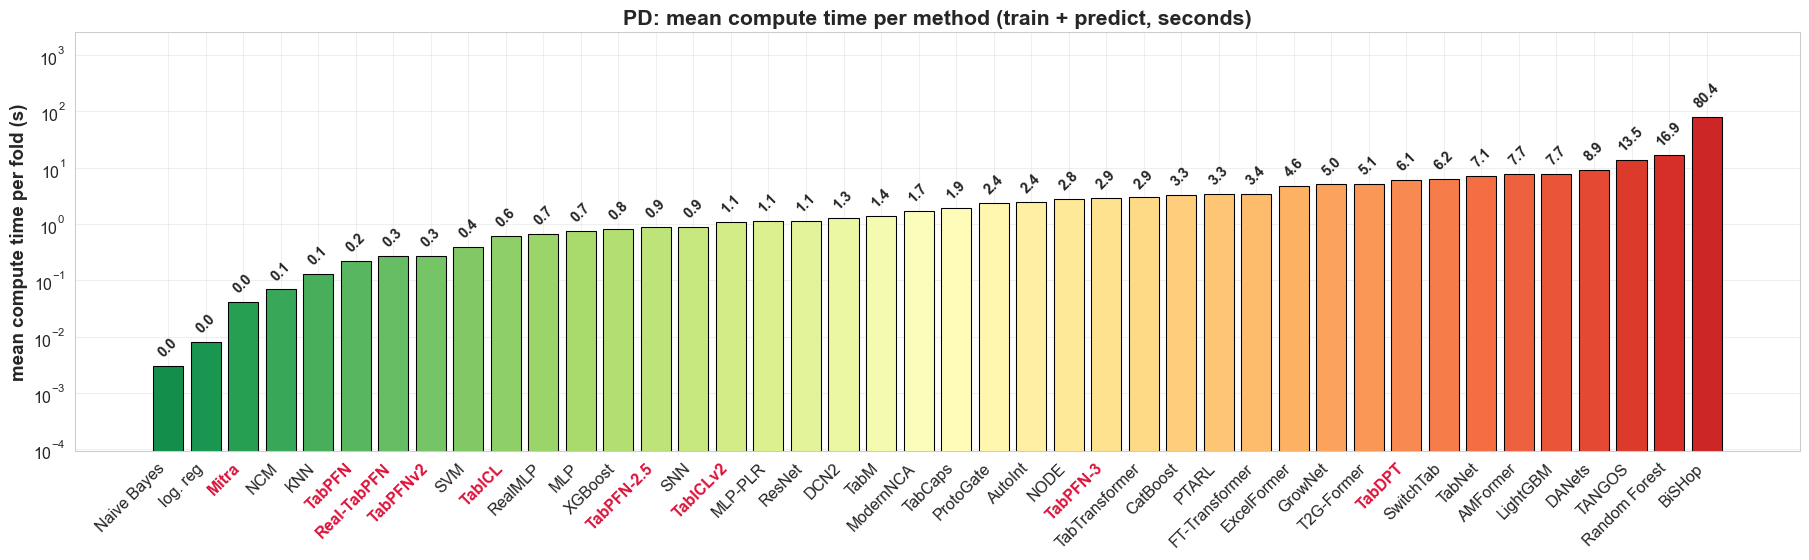

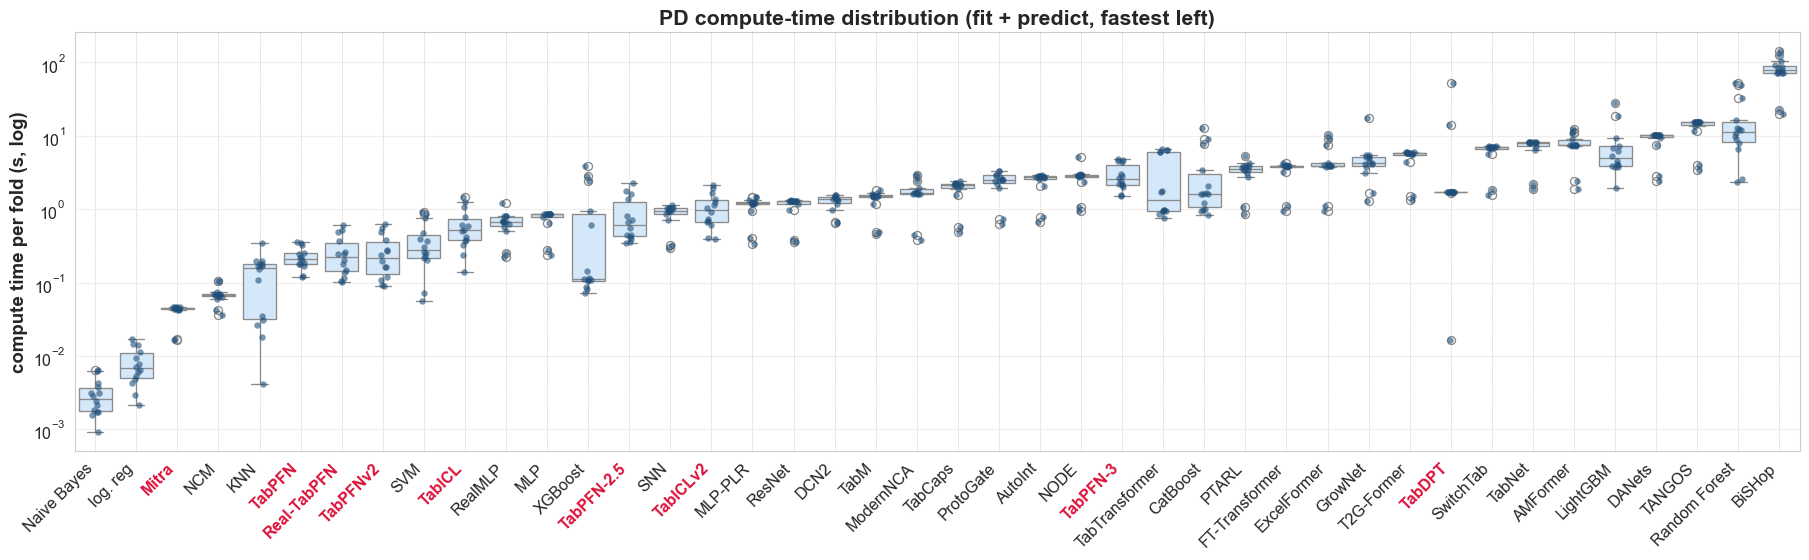

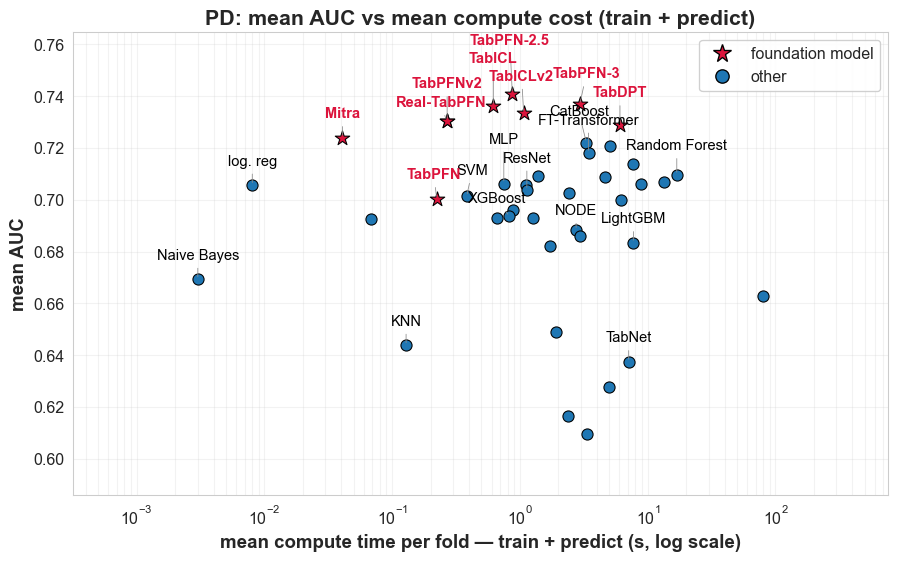

WindowsPath('C:/Users/U0152019/PhD Documents/Projects/1. TabPFN/TabPFNCredit/figures/experiment0/pd_cost_quality_auc.pdf')

In [5]:
compute_time_bars(df, task_name='PD', out_dir=FIGURES_DIR)
compute_time_boxplot(df, task_name='PD', out_dir=FIGURES_DIR)
runtime_performance_scatter(df, 'AUC', task_name='PD', out_dir=FIGURES_DIR)

## LGD — R²

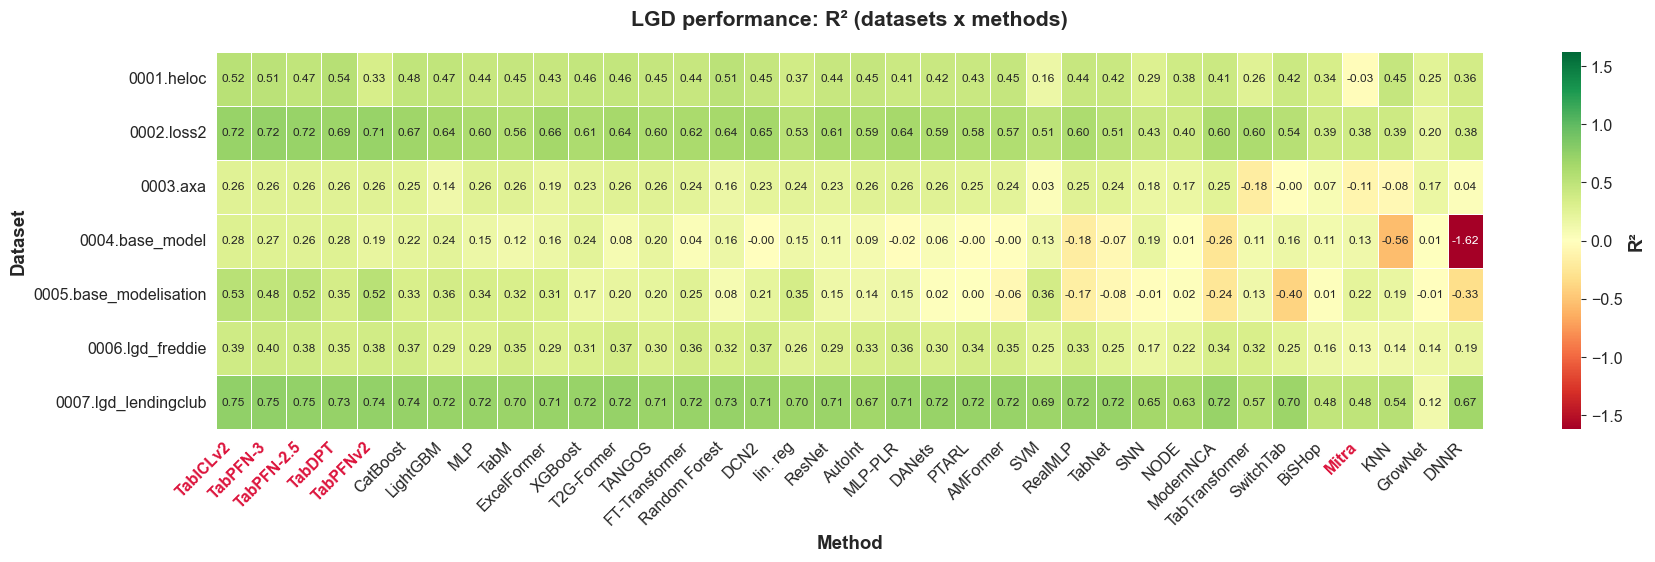

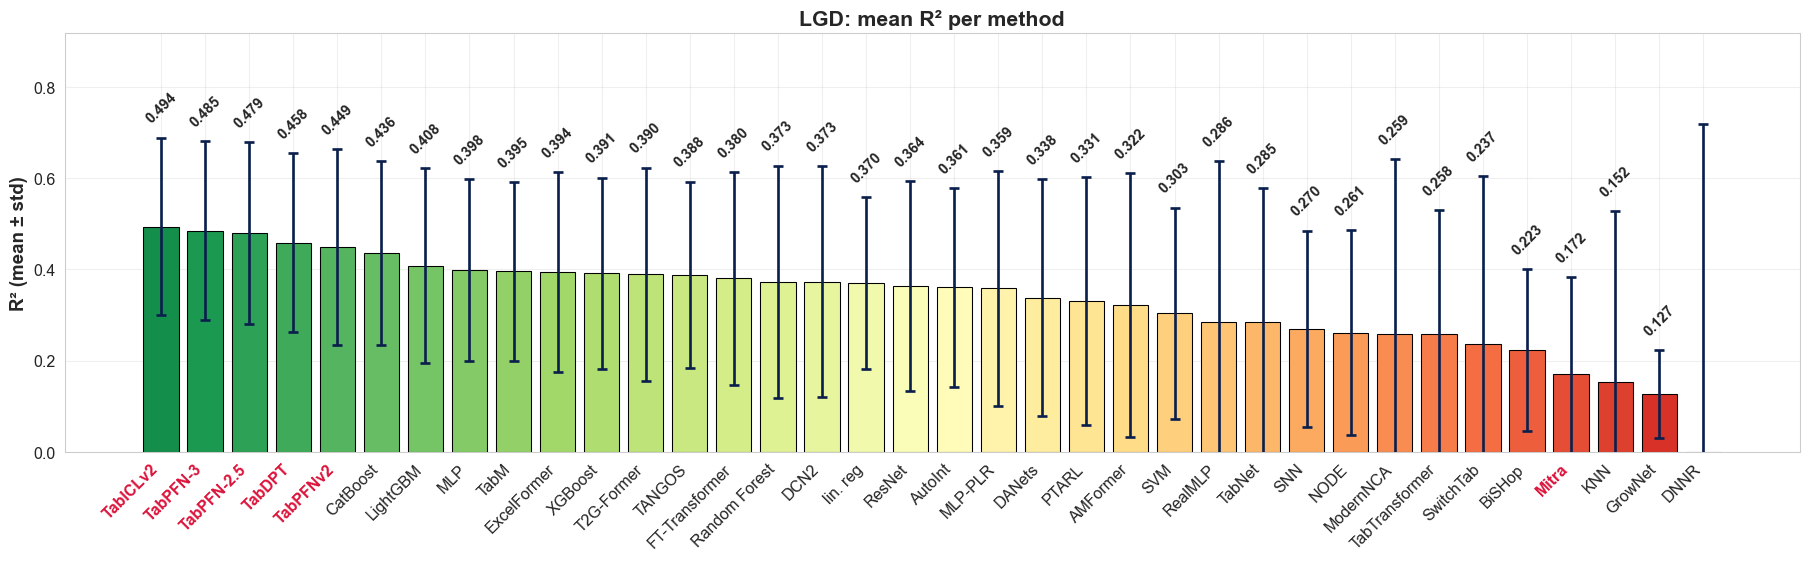

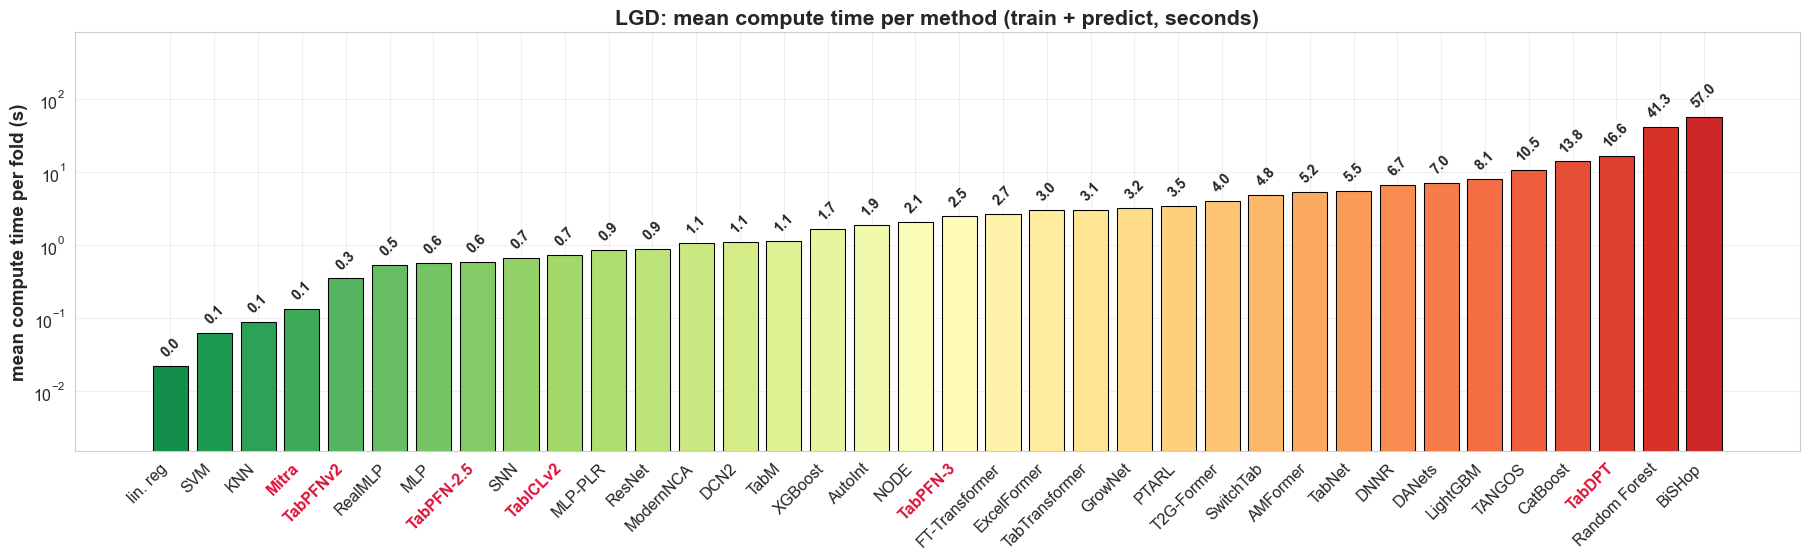

In [6]:
if df_lgd is not None:
    performance_heatmap(df_lgd, 'R2', task_name='LGD', higher_is_better=True, out_dir=FIGURES_DIR)
    metric_bars(df_lgd, 'R2', task_name='LGD', higher_is_better=True, out_dir=FIGURES_DIR)
    compute_time_bars(df_lgd, task_name='LGD', out_dir=FIGURES_DIR)

## Summary

In [7]:
pd_summary_text(df, task_name='Experiment 0 — PD (pilot)')
if df_lgd is not None:
    print();    lgd_summary_text(df_lgd, task_name='Experiment 0 — LGD (pilot)')

Experiment 0 — PD (pilot) — mean of every metric per method   (datasets: 14, methods: 42)
                   AUC    Gini      KS  Normalized AP      F1  Accuracy  Balanced_Accuracy     MCC   Brier     ECE  LogLoss  Precision  Recall  Optimal_Threshold      AP  AP_baseline  AP_minus_baseline  Expected_Loss_Normalized  Optimal_Profit_Threshold  Optimal_Profit  H_Measure  time_s (mean)
method                                                                                                                                                                                                                                                                                                 
tabpfn_v2_5     0.7410  0.4821  0.3943         0.3394  0.4929    0.7329             0.6554  0.3144  0.1301  0.0308   0.4053     0.4596  0.5902             0.2543  0.4826       0.2207             0.2619                    0.7743                    0.1507       -372.0786     0.2766         0.8708
tabpfn_v3       0.7368